In [1]:
from google.colab import files
uploaded = files.upload()

Saving iris.csv to iris.csv


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = pd.read_csv("iris.csv")

X = data.drop("species", axis=1)
y = data["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [5]:
rf_default = RandomForestClassifier(n_estimators=10, random_state=42)
rf_default.fit(X_train, y_train)

y_pred_default = rf_default.predict(X_test)

accuracy_default = accuracy_score(y_test, y_pred_default)
print("Accuracy with 10 trees:", accuracy_default)

Accuracy with 10 trees: 1.0


In [6]:
best_score = 0
best_n = 0

for n in [10, 20, 50, 100, 150, 200]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Trees: {n}, Accuracy: {acc}")

    if acc > best_score:
        best_score = acc
        best_n = n

Trees: 10, Accuracy: 1.0
Trees: 20, Accuracy: 1.0
Trees: 50, Accuracy: 1.0
Trees: 100, Accuracy: 1.0
Trees: 150, Accuracy: 1.0
Trees: 200, Accuracy: 1.0


In [7]:
print("\nBest Accuracy:", best_score)
print("Best Number of Trees:", best_n)


Best Accuracy: 1.0
Best Number of Trees: 10


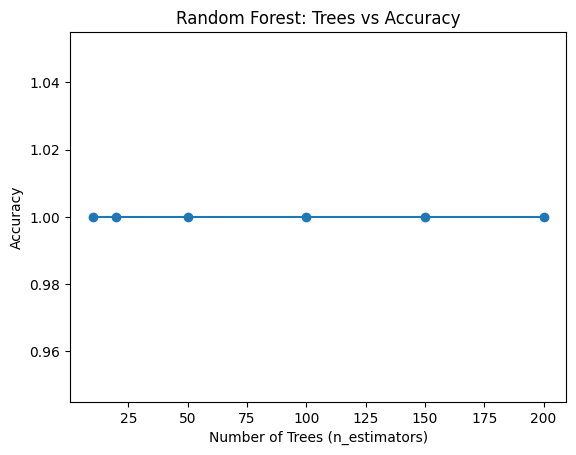

In [9]:
import matplotlib.pyplot as plt

trees = [10, 20, 50, 100, 150, 200]
accuracies = []

for n in trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)

plt.figure()
plt.plot(trees, accuracies, marker='o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest: Trees vs Accuracy")
plt.show()